<a href="https://colab.research.google.com/github/Samarthgarg27/stock_price_prediction/blob/main/Stock_Price_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [3]:
ticker = "TCS.NS"

In [4]:
data = yf.download(
    ticker,
    start="2015-01-01",
    end="2026-01-01"
)

data.head()

/tmp/ipykernel_1198/3414951921.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2015-01-01,970.330566,978.507009,968.596147,978.507009,366830
2015-01-02,983.252991,987.636642,972.255799,972.408237,925740
2015-01-05,968.309814,991.047571,962.363263,983.843177,1754242
2015-01-06,932.612244,964.060174,930.096372,964.060174,2423784
2015-01-07,921.595764,945.019686,917.688598,941.531862,2636332


In [5]:
print("Shape:", data.shape)

Shape: (2716, 5)


In [6]:
print(data.columns)

MultiIndex([( 'Close', 'TCS.NS'),
            (  'High', 'TCS.NS'),
            (   'Low', 'TCS.NS'),
            (  'Open', 'TCS.NS'),
            ('Volume', 'TCS.NS')],
           names=['Price', 'Ticker'])


In [7]:
print(data.isnull().sum())

Price   Ticker
Close   TCS.NS    0
High    TCS.NS    0
Low     TCS.NS    0
Open    TCS.NS    0
Volume  TCS.NS    0
dtype: int64


In [8]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
count,2716.000000,2716.000000,2716.000000,2716.000000,2.716000e+03
mean,2183.676893,2205.066315,2163.049843,2184.584030,2.669936e+06
std,1011.398472,1019.906776,1003.715998,1011.741785,2.309601e+06
min,828.282593,843.597474,808.868341,834.491638,0.000000e+00
25%,1040.525909,1052.534934,1030.854878,1040.230999,1.652812e+06
50%,1892.347839,1917.182824,1870.306999,1892.164937,2.247911e+06
75%,3065.700073,3093.280970,3039.229358,3063.298901,3.091951e+06
max,4230.709473,4266.478304,4191.921285,4251.381161,8.806715e+07


In [9]:
data = data.dropna()

In [10]:
print(data.isnull().sum())

Price   Ticker
Close   TCS.NS    0
High    TCS.NS    0
Low     TCS.NS    0
Open    TCS.NS    0
Volume  TCS.NS    0
dtype: int64


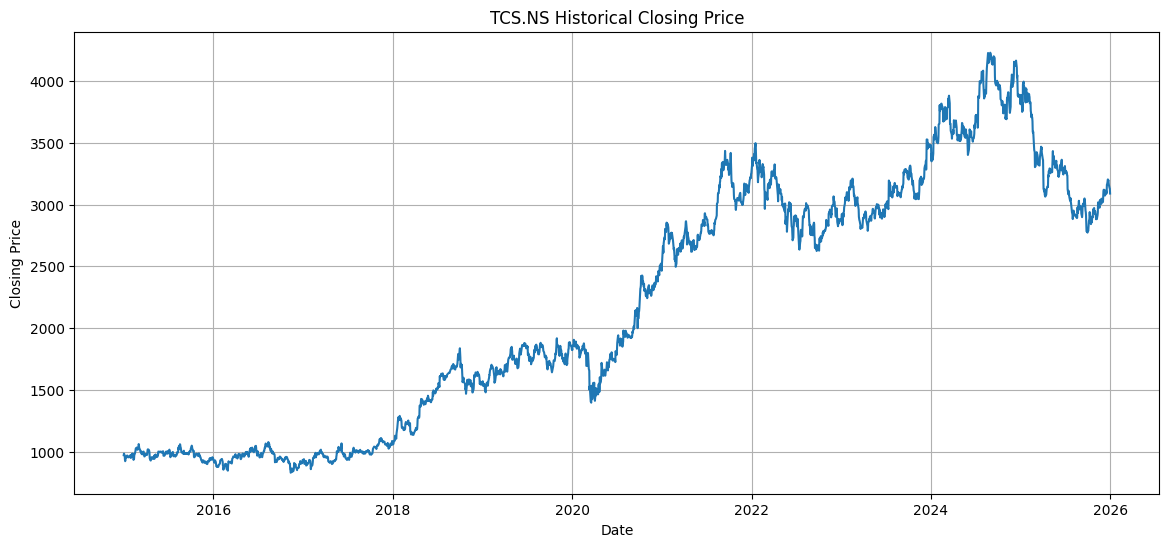

In [11]:
plt.figure(figsize=(14, 6))

plt.plot(data["Close"])

plt.title(f"{ticker} Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid()
plt.show()

In [12]:
data["Previous_Close"] = data["Close"].shift(1)

In [13]:
data["MA_5"] = data["Close"].rolling(window=5).mean()

In [14]:
data["MA_10"] = data["Close"].rolling(window=10).mean()

In [15]:
data["MA_20"] = data["Close"].rolling(window=20).mean()

In [16]:
data["Daily_Return"] = data["Close"].pct_change()

In [17]:
data.head(25)

Price,Close,High,Low,Open,Volume,Previous_Close,MA_5,MA_10,MA_20,Daily_Return
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,,,,,
Date,,,,,,,,,,
2015-01-01,970.330566,978.507009,968.596147,978.507009,366830,NaN,NaN,NaN,NaN,NaN
2015-01-02,983.252991,987.636642,972.255799,972.408237,925740,970.330566,NaN,NaN,NaN,0.013318
2015-01-05,968.309814,991.047571,962.363263,983.843177,1754242,983.252991,NaN,NaN,NaN,-0.015198
2015-01-06,932.612244,964.060174,930.096372,964.060174,2423784,968.309814,NaN,NaN,NaN,-0.036866
2015-01-07,921.595764,945.019686,917.688598,941.531862,2636332,932.612244,955.220276,NaN,NaN,-0.011812
2015-01-08,931.544800,933.526954,922.682202,931.011082,1565408,921.595764,947.463123,NaN,NaN,0.010795
2015-01-09,957.656067,960.553032,933.908099,935.814034,3197642,931.544800,942.343738,NaN,NaN,0.028030
2015-01-12,956.664978,963.640719,945.439040,959.447662,1596006,957.656067,940.014771,NaN,NaN,-0.001035


In [18]:
data = data.dropna()

In [19]:
data["Target"] = data["Close"].shift(-1)

In [20]:
data = data.dropna()

In [21]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Previous_Close",
    "MA_5",
    "MA_10",
    "MA_20",
    "Daily_Return"
]

In [22]:
X = data[features]
y = data["Target"]

In [23]:
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [24]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2156
Testing samples: 540


In [25]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [26]:
linear_predictions = linear_model.predict(X_test)

In [27]:
mae = mean_absolute_error(y_test, linear_predictions)

print("MAE:", mae)

MAE: 32.508156731251496


In [28]:
mse = mean_squared_error(y_test, linear_predictions)

print("MSE:", mse)

MSE: 2080.4373085894445


In [29]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 45.611811064563575


In [30]:
r2 = r2_score(y_test, linear_predictions)

print("R2 Score:", r2)

R2 Score: 0.9856924121343084


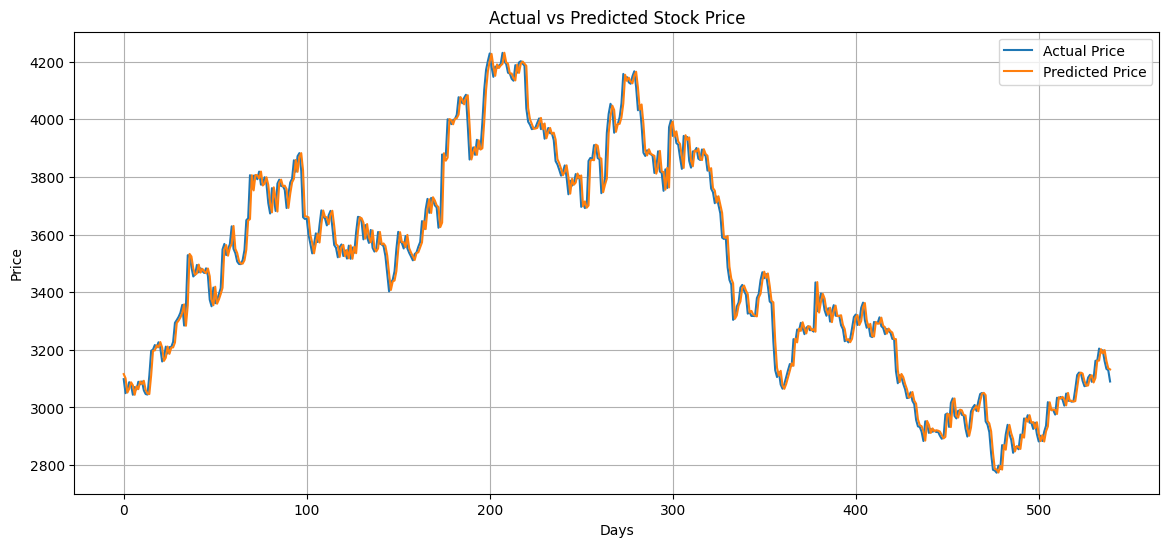

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values,
    label="Actual Price"
)

plt.plot(
    linear_predictions,
    label="Predicted Price"
)

plt.title("Actual vs Predicted Stock Price")
plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()
plt.grid()

plt.show()

In [32]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [33]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [34]:
rf_predictions = rf_model.predict(X_test)

In [35]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_mse = mean_squared_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest Results
---------------------
MAE : 237.78489251256875
MSE : 117163.82746637642
RMSE: 342.29202074599465
R2  : 0.19424067755615781


In [36]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        mae,
        rf_mae
    ],

    "RMSE": [
        rmse,
        rf_rmse
    ],

    "R2 Score": [
        r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,32.508157,45.611811,0.985692
1,Random Forest,237.784893,342.292021,0.194241


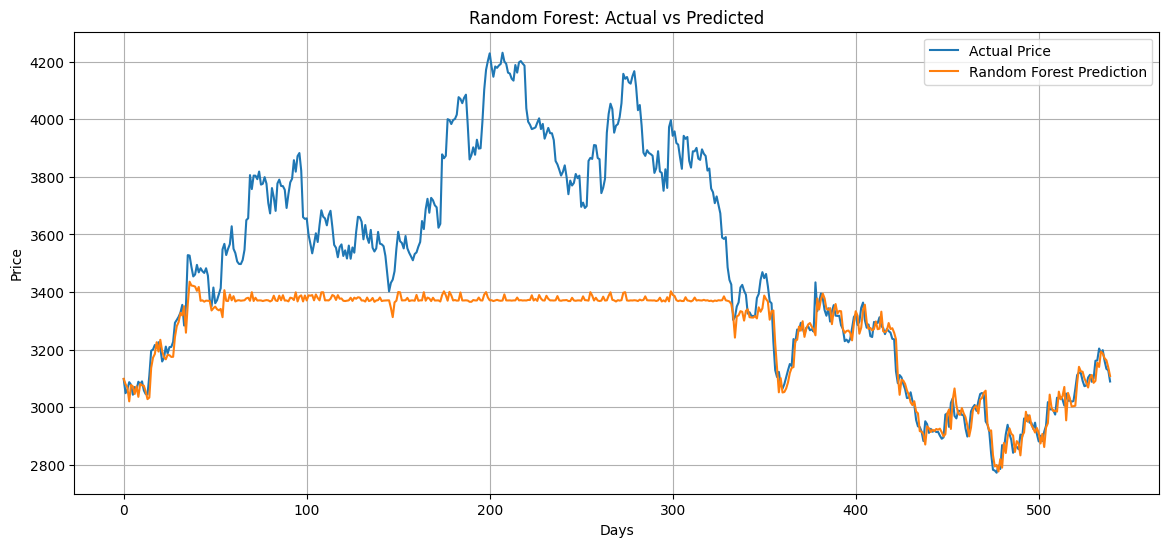

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values,
    label="Actual Price"
)

plt.plot(
    rf_predictions,
    label="Random Forest Prediction"
)

plt.title("Random Forest: Actual vs Predicted")

plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()
plt.grid()

plt.show()

In [38]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Low,0.464850
3,Close,0.314624
6,MA_5,0.069164
1,High,0.043013
8,MA_20,0.036442
0,Open,0.029242
7,MA_10,0.021381
5,Previous_Close,0.021038
4,Volume,0.000141
9,Daily_Return,0.000104


In [39]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Low,0.464850
3,Close,0.314624
6,MA_5,0.069164
1,High,0.043013
8,MA_20,0.036442
0,Open,0.029242
7,MA_10,0.021381
5,Previous_Close,0.021038
4,Volume,0.000141
9,Daily_Return,0.000104


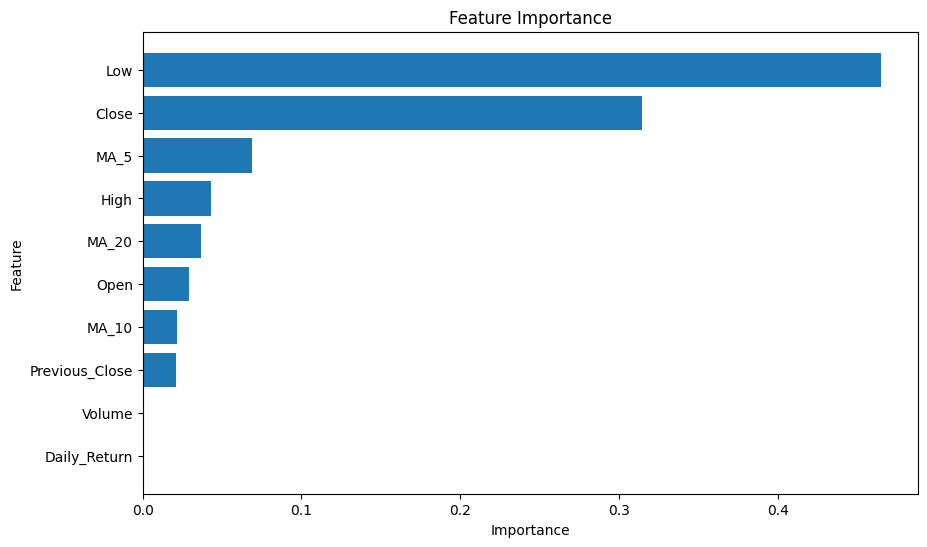

In [40]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [41]:
latest_data = data[features].iloc[-1:]

next_day_prediction = rf_model.predict(latest_data)

print(
    "Predicted next closing price:",
    next_day_prediction[0]
)

Predicted next closing price: 3108.8811682128908


In [42]:
joblib.dump(
    rf_model,
    "stock_price_model.pkl"
)

['stock_price_model.pkl']

In [43]:
data.to_csv(
    "stock_data_processed.csv",
    index=True
)